# Roman Coronagraph Slew Time Calculator

This notebook builds on the example notebook from https://github.com/roman-corgi/roman_pointing to allow the user to calculate the pitch and yaw angle locations of any two targets with respect to the observatory as a function of time in order to calculate the slew distance (and by extension, an estimate of the slew time). Slew and settle time information utilizes the file ``SlewSettle.ecsv" from https://science.nasa.gov/mission/roman-space-telescope/observatory-technical/ You will need to install roman-pointing to your environment to utilize this notebook. You will also need astropy, astroquery, matplotlib, and numpy (which would be installed be default with roman-pointing) along with pandas and scipy.

In [1]:
from roman_pointing.roman_pointing import calcRomanAngles, getL2Positions
import astropy.units as u
from astropy.time import Time
from astroquery.simbad import Simbad
from astropy.coordinates import (
    SkyCoord,
    Distance,
    get_body_barycentric,
    BarycentricMeanEcliptic,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas
import scipy.optimize as optimize
import time

/Users/jrhom/anaconda3/envs/Disk_ETCs_Cartopy/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Helper functions to query Simbad for target data

This function will query Simbad for the necessary information (ra, dec, pmra, pmdec, parallax, and radial velocity) for a star target. A Simbad-resolvable name is required.

In [2]:
def queryTap_byname(name):
    example_base = """SELECT TOP 1 oid, main_id, ids, ra, dec, coo_err_maj, coo_err_min, coo_err_angle, coo_qual, coo_bibcode,
                        pmra, pmdec, pm_err_maj, pm_err_min, pm_err_angle, pm_qual, pm_bibcode, plx_value, plx_err, plx_qual, plx_bibcode,
                        rvz_radvel, rvz_err, rvz_bibcode,
                        otype, otypes, sp_type, sp_bibcode, 
                        U, B, V, G, R, I, J, H, K, u_, g_, r_, i_, z_
                        FROM basic JOIN alltypes ON basic.oid = alltypes.oidref JOIN allfluxes ON basic.oid = allfluxes.oidref
                        JOIN ident ON basic.oid = ident.oidref JOIN ids ON basic.oid = ids.oidref
                        WHERE id = '{insertname}'
                        AND ra IS NOT NULL
                        AND dec IS NOT NULL;"""
    example = example_base.format(insertname=name)
    queryresult = Simbad.query_tap(example)
    time.sleep(1)
    return queryresult

This helper function will fit a line to a curve. Scipy.optimize.curve_fit will be used with this function to fid the GSFC data on slew/settle times as a function of slew angle.

In [3]:
def baseSlewfunction(x,m,b):
    return (m*x)+b

This function takes an input slew angle, interpolates over the GSFC data, and calculates a time estimate for the slew. A visual demonstration of this is shown later in the notebook.

In [4]:
def slewSettleinterpolator(angle=50):
    angles = np.loadtxt('SlewSettle.ecsv',skiprows=11,usecols=0,delimiter=',')
    times = np.loadtxt('SlewSettle.ecsv',skiprows=11,usecols=1,delimiter=',')
    popt,pcov = optimize.curve_fit(baseSlewfunction,angles[angles>6.5],times[angles>6.5])
    print('Best fit linear params: ',popt)
    return baseSlewfunction(angle,*popt)

Now let's find the distance between two targets. We'll start with Simbad resolvable names for two stars, in addition to a date over which to calculate the maximum slew angle and a range of dates over which we could calculate a slew angles.

In [13]:
targ1 = 'ups And'
targ2 = 'bet Car'
daystr = '2027-01-26'

#Define the starting date range and observatory position
t_str = ["2026-12-01T00:00:00.0"]
t0 = Time(t_str, format="isot", scale="utc")
ts = t0 + np.arange(365)*u.d
roman_pos = getL2Positions(ts) #Grab the observatory position as a function of your provided date range

Query target information and calculate yaw and pitch angles for the targets.

In [14]:
result1 = queryTap_byname(targ1)
#Need to replace nan values with placeholder values that assume 0 pm, 0 rvz, very small parallax
result_pandas1 = result1.to_pandas()
if np.isnan(result_pandas1.loc[0,"plx_value"]) == True:
    result_pandas1.loc[0,"plx_value"] = 0.0001
if np.isnan(result_pandas1.loc[0,"pmra"]) == True:
    result_pandas1.loc[0,"pmra"] = 0.0
if np.isnan(result_pandas1.loc[0,"pmdec"]) == True:
    result_pandas1.loc[0,"pmdec"] = 0.0
if np.isnan(result_pandas1.loc[0,"rvz_radvel"]) == True:
    result_pandas1.loc[0,"rvz_radvel"] = 0.0

target1 = SkyCoord(
                result_pandas1.loc[0,"ra"],
                result_pandas1.loc[0,"dec"],
                unit=(u.deg, u.deg),
                frame="icrs",
                distance=Distance(parallax=result_pandas1.loc[0,"plx_value"] * u.mas),
                pm_ra_cosdec=result_pandas1.loc[0,"pmra"] * u.mas/u.yr,
                pm_dec=result_pandas1.loc[0,"pmdec"] * u.mas/u.yr,
                radial_velocity=result_pandas1.loc[0,"rvz_radvel"] * u.km/u.s,
                equinox="J2000",
                obstime="J2000",
                ).transform_to(BarycentricMeanEcliptic)

result2 = queryTap_byname(targ2)
#Need to replace nan values with placeholder values that assume 0 pm, 0 rvz, very small parallax
result_pandas2 = result2.to_pandas()
if np.isnan(result_pandas2.loc[0,"plx_value"]) == True:
    result_pandas2.loc[0,"plx_value"] = 0.0001
if np.isnan(result_pandas2.loc[0,"pmra"]) == True:
    result_pandas2.loc[0,"pmra"] = 0.0
if np.isnan(result_pandas2.loc[0,"pmdec"]) == True:
    result_pandas2.loc[0,"pmdec"] = 0.0
if np.isnan(result_pandas2.loc[0,"rvz_radvel"]) == True:
    result_pandas2.loc[0,"rvz_radvel"] = 0.0

target2 = SkyCoord(
                result_pandas2.loc[0,"ra"],
                result_pandas2.loc[0,"dec"],
                unit=(u.deg, u.deg),
                frame="icrs",
                distance=Distance(parallax=result_pandas2.loc[0,"plx_value"] * u.mas),
                pm_ra_cosdec=result_pandas2.loc[0,"pmra"] * u.mas/u.yr,
                pm_dec=result_pandas2.loc[0,"pmdec"] * u.mas/u.yr,
                radial_velocity=result_pandas2.loc[0,"rvz_radvel"] * u.km/u.s,
                equinox="J2000",
                obstime="J2000",
                ).transform_to(BarycentricMeanEcliptic)
sun_ang_targ1, yaw_targ1, pitch_targ1, B_C_I_targ1 = calcRomanAngles(target1, ts, roman_pos) #Calculate angles for science target
sun_ang_targ2, yaw_targ2, pitch_targ2, B_C_I_targ2 = calcRomanAngles(target2, ts, roman_pos) #Calculate angles for science target

Slew motion is decided by how much the observatory moves in both pitch and yaw at a given time (pitch and yaw motion is NOT constant as a function of time between two arbitrary points on the sky). The observatory moves in all three axes (pitch, yaw, and roll) simultaneously, and is timed such that the longest change in angle drives the maximum amount of time spent slewing. Let's calculate the difference in both yaw and pitch as a function of time, keeping in mind that yaw wraps around from -180 to 180 degrees. If your $\Delta$yaw is > 180 degrees, you are going the long way around! Pitch DOES NOT wrap around. This is because if you move the observatory wrapping around in pitch, you will cross a keepout zone!

In [15]:
yaw_diff = np.abs(yaw_targ1-yaw_targ2).to(u.deg)
pitch_diff = np.abs(pitch_targ1-pitch_targ2).to(u.deg)
yaw_diff[yaw_diff>(180*u.deg)] = (360*u.deg)-yaw_diff[yaw_diff>(180*u.deg)]

Let's take a look at what the yaw and pitch for both targets look like as a function of time.

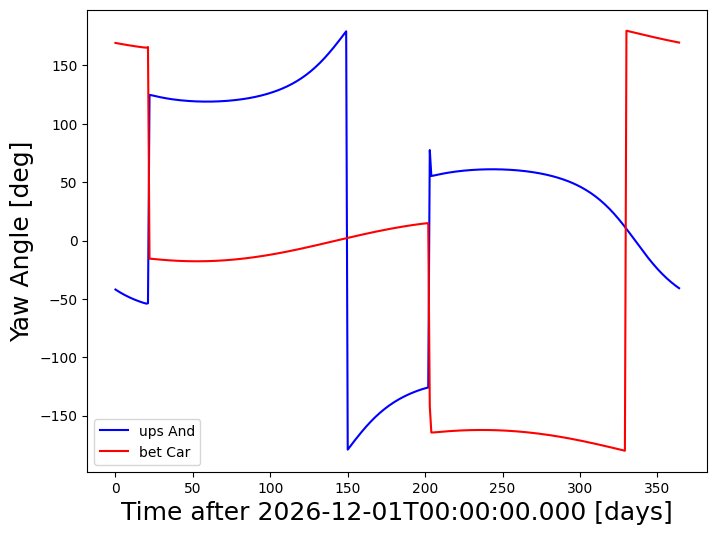

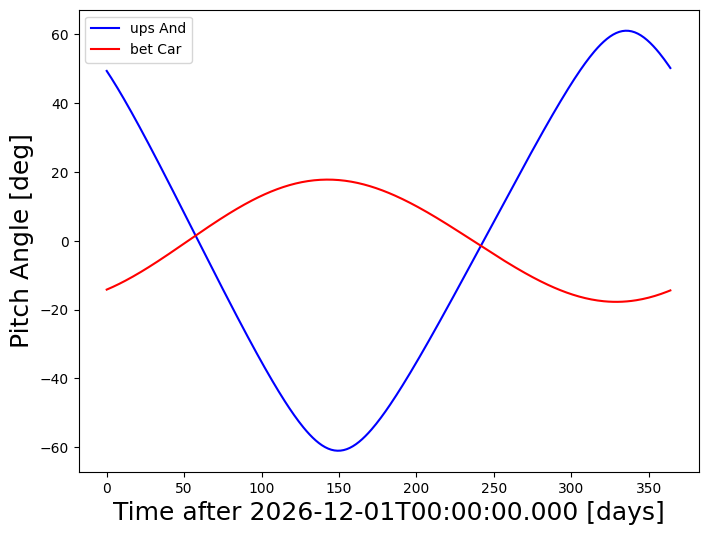

In [16]:
time2027 = range(len(ts))
fig2,ax2 = plt.subplots(1,1,figsize=(8,6))
ax2.plot(time2027,yaw_targ1.to(u.deg),'b',label=targ1)
ax2.plot(time2027,yaw_targ2.to(u.deg),'r',label=targ2)
ax2.set_xlabel(f"Time after {ts[0].value} [days]",fontsize=18)
ax2.set_ylabel("Yaw Angle [deg]",fontsize=18)
ax2.legend(loc='best')


fig3,ax3 = plt.subplots(1,1,figsize=(8,6))
ax3.plot(time2027,pitch_targ1.to(u.deg),'b',label=targ1)
ax3.plot(time2027,pitch_targ2.to(u.deg),'r',label=targ2)
ax3.set_xlabel(f"Time after {ts[0].value} [days]",fontsize=18)
ax3.set_ylabel("Pitch Angle [deg]",fontsize=18)
ax3.legend(loc='best')

Slew time is driven by the largest angle change, so let's calculate what that is between slew and yaw.

In [17]:
maxangle = np.max([yaw_diff,pitch_diff],axis=0)

Let's visualize the yaw and pitch differences as a function of time, and remember that the angle that drives the slew time estimate is the maximum between pitch and yaw change.

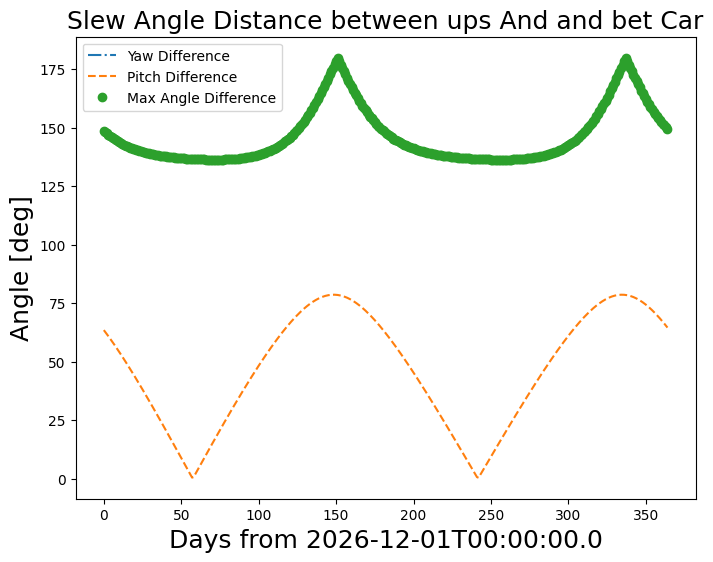

In [18]:
fig,ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(time2027,yaw_diff,'-.',label='Yaw Difference')
ax.plot(time2027,pitch_diff,'--',label='Pitch Difference')
ax.plot(time2027,maxangle,'o',label='Max Angle Difference')
ax.set_xlabel('Days from '+t_str[0],fontsize=18)
ax.set_ylabel('Angle [deg]',fontsize=18)
ax.set_title('Slew Angle Distance between '+targ1+' and '+targ2,fontsize=18)
ax.legend(loc='best')

Now let's show how the interpolator works. GSFC has provided a curve of points where the slew time as a function of slew angle is calculated up to 90 degrees. At greater than ~6.5 degrees, this trend is linear because it is mostly limited by torque. For the Roman Coronagraph, we expect a majority of our slews to be well above this threshold, so using this interpolator should be valid. For slew angles less than this time, a different function must be used, but likely using the finely-spaced values less than 6.5 degrees in the table should be sufficient.

Best fit linear params:  [20.02889814 43.876087  ]


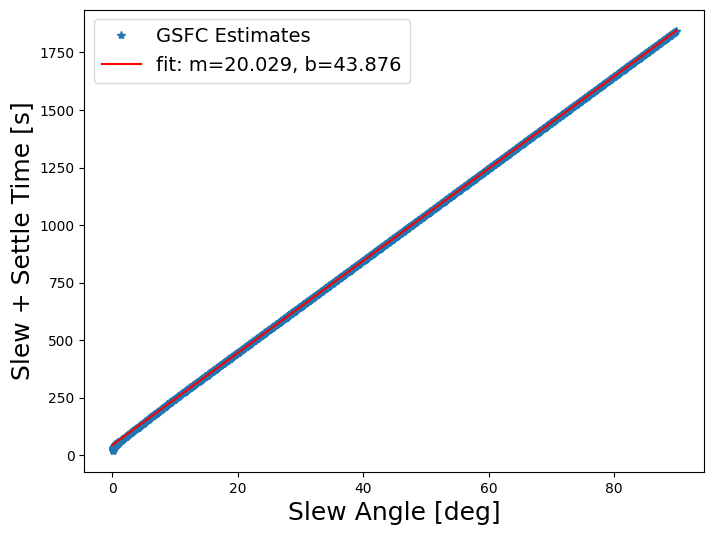

In [19]:
#Load in the data
angles = np.loadtxt('SlewSettle.ecsv',skiprows=11,usecols=0,delimiter=',')
times = np.loadtxt('SlewSettle.ecsv',skiprows=11,usecols=1,delimiter=',')
fig,ax = plt.subplots(1,1,figsize=(8,6))
#Fit the line
popt,pcov = optimize.curve_fit(baseSlewfunction,angles[angles>1],times[angles>1])
print('Best fit linear params: ',popt)
ax.plot(angles,times,'*',label='GSFC Estimates')
ax.plot(angles,baseSlewfunction(angles,*popt),'r-',label='fit: m=%5.3f, b=%5.3f' % tuple(popt))
ax.set_xlabel('Slew Angle [deg]',fontsize=18)
ax.set_ylabel('Slew + Settle Time [s]',fontsize=18)
ax.legend(loc='best',fontsize=14)

We can now use the best-fit line parameters to estimate how much slew time is needed for any arbitrary angle change, as already defined in the helper function above.

In [20]:
dayindex = np.where(ts==daystr+"T00:00:00.0")[0][0] #This is the input day you specified above
print('Max Slew Angle Distance on ',t0+dayindex*u.d,': ',maxangle[dayindex],' deg')
slewtime_corr = slewSettleinterpolator(angle=maxangle[dayindex])
print('Max Slew Time on ',t0+dayindex*u.d,': ',slewtime_corr*u.s)

Max Slew Angle Distance on  ['2027-01-26T00:00:00.000'] :  136.747749525111  deg
Best fit linear params:  [20.00525332 45.32097309]
Max Slew Time on  ['2027-01-26T00:00:00.000'] :  2780.9943432716364 s
